# Smoke and Mobility in California

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation
import json
from IPython.display import HTML

### Import California shapefile

In [2]:
grid = gpd.read_file('./data/tract/tl_2019_06_tract/tl_2019_06_tract.shp')[['GEOID','geometry']]
grid['GEOID'] = grid['GEOID'].astype(str).str.lstrip('0')
grid.head()

,GEOID,geometry
0,6037139301,"POLYGON ((-118.5715 34.17758, -118.57148 34.17..."
1,6037139302,"POLYGON ((-118.54073 34.1802, -118.5407 34.180..."
2,6037139502,"POLYGON ((-118.53224 34.16201, -118.53177 34.1..."
3,6037139600,"POLYGON ((-118.51858 34.15858, -118.51858 34.1..."
4,6037139701,"POLYGON ((-118.5098 34.15691, -118.50848 34.15..."


### Import smoke data

In [3]:
smoke_raw = pd.read_csv('./data/tract/smokePM2pt5_predictions_daily_tract_20060101-20201231.csv')

In [4]:
smoke = smoke_raw.copy()
smoke['date'] = pd.to_datetime(smoke['date'], format='%Y%m%d')
smoke = smoke[(smoke['date'] >= '2020-08-01') & (smoke['date'] <= '2020-09-30')]
smoke['GEOID'] = smoke['GEOID'].astype(str).str.lstrip('0')
smoke.head()

,GEOID,date,smokePM_pred
31119021,1003010400,2020-08-01,0.114168
31119022,1053969800,2020-08-01,0.881515
31119023,1053969900,2020-08-01,0.357934
31119024,1053970200,2020-08-01,0.007577
31119025,1053970300,2020-08-01,0.170963


### Import mobility data

In [5]:
mobility_raw = pd.read_csv('./data/california_202008_202009.csv')

In [6]:
mobility = mobility_raw.copy()
mobility['DATE_RANGE_START'] = pd.to_datetime(mobility['DATE_RANGE_START'])
mobility['AREA'] = mobility['AREA'].astype(str).str.lstrip('0')
mobility['STOPS_LIST'] = mobility['STOPS_BY_DAY'].apply(lambda x: json.loads(x) if isinstance(x, str) else x) # convert to a python list

# we need there to be one row per day
mobility = mobility[['AREA','DATE_RANGE_START','STOPS_LIST']].copy()
mobility = mobility.explode('STOPS_LIST').reset_index(drop=True)
mobility['Day'] = mobility.groupby(['AREA','DATE_RANGE_START']).cumcount()
mobility['date'] = mobility['DATE_RANGE_START'] + pd.to_timedelta(mobility['Day'], unit='d')

mobility = mobility.rename(columns={'STOPS_LIST': 'mobility_raw'})
mobility = mobility[['AREA', 'mobility_raw', 'date']]

mobility.head()

,AREA,mobility_raw,date
0,60650432181,1377,2020-08-01
1,60650432181,1531,2020-08-02
2,60650432181,1377,2020-08-03
3,60650432181,1469,2020-08-04
4,60650432181,1490,2020-08-05


In [7]:
# there is an extra digit of precision we need to get rid of
mobility['GEOID'] = mobility['AREA'].astype(str).str[:10]
mobility = (mobility.groupby(['GEOID', 'date'])['mobility_raw'].mean().reset_index())
mobility.head()

,GEOID,date,mobility_raw
0,6001400100,2020-08-01,2559.0
1,6001400100,2020-08-02,2621.0
2,6001400100,2020-08-03,3052.0
3,6001400100,2020-08-04,2538.0
4,6001400100,2020-08-05,2580.0


To get the mobility anomaly, we need to choose baseline mobility. For now, since there was relatively very little PM2.5 in the first two weeks of August 2020, we will average the mobility of each weekday of these two weeks and use that as the baseline.

In [8]:
mobility['weekday'] = mobility['date'].dt.day_name()
mobility_august = mobility[(mobility['date'] >= '2020-08-01') & (mobility['date'] <= '2020-08-14')]
baseline = (
    mobility_august
    .groupby(['GEOID', 'weekday'])['mobility_raw']
    .mean()
    .reset_index()
    .rename(columns={'mobility_raw': 'baseline'})
)
mobility = mobility.merge(
    baseline,
    on=['GEOID', 'weekday'],
    how='left'
)
mobility['mobility_anomaly'] = mobility['mobility_raw'] - mobility['baseline']
mobility['anomaly_pct'] = 100 * (
    (mobility['mobility_raw'] - mobility['baseline']) /
    (mobility['baseline']+1e-6)
)

mobility = mobility.sort_values('date')
mobility = mobility[['GEOID','date','anomaly_pct']]

mobility.head()

,GEOID,date,anomaly_pct
0,6001400100,2020-08-01,-6.911604
212829,6037980002,2020-08-01,4.394665
278648,6065040807,2020-08-01,-12.542155
461526,6097152802,2020-08-01,-3.328957
29951,6013321101,2020-08-01,1.288155


In [9]:
mobility.shape

(491477, 3)

### Merge smoke and mobility onto the map

Create grid with all GEOIDs and all dates

In [10]:
geo = grid[['GEOID', 'geometry']].copy()
geoids = grid['GEOID'].astype(str).unique()
dates = pd.date_range('2020-08-01', '2020-9-30')
space_time_grid = pd.MultiIndex.from_product(
    [geoids, dates],
    names=['GEOID', 'date']
).to_frame(index=False)

Merge with smoke and mobility

In [11]:
grid_full = space_time_grid.merge(smoke, on=['GEOID','date'], how='left')
grid_full['smokePM_pred'] = grid_full['smokePM_pred'].fillna(0)
grid_full = grid_full.merge(mobility, on=['GEOID','date'],how='left')
grid_full.head()

,GEOID,date,smokePM_pred,anomaly_pct
0,6037139301,2020-08-01,0.000000,-2.165784
1,6037139301,2020-08-02,3.408873,1.17551
2,6037139301,2020-08-03,3.814140,0.29292
3,6037139301,2020-08-04,0.000000,-4.457663
4,6037139301,2020-08-05,1.961241,0.883971


In [12]:
grid_final = grid_full.merge(geo, on='GEOID', how='left')
grid_final['anomaly_pct'] = grid_final['anomaly_pct'].astype(float)
grid_final = gpd.GeoDataFrame(grid_final, geometry='geometry')

## Animate data

In [13]:
states = gpd.read_file("./data/tl_2025_us_state/tl_2025_us_state.shp")
california = states[states["NAME"] == "California"]
california = california.to_crs(grid.crs)

### Only smoke

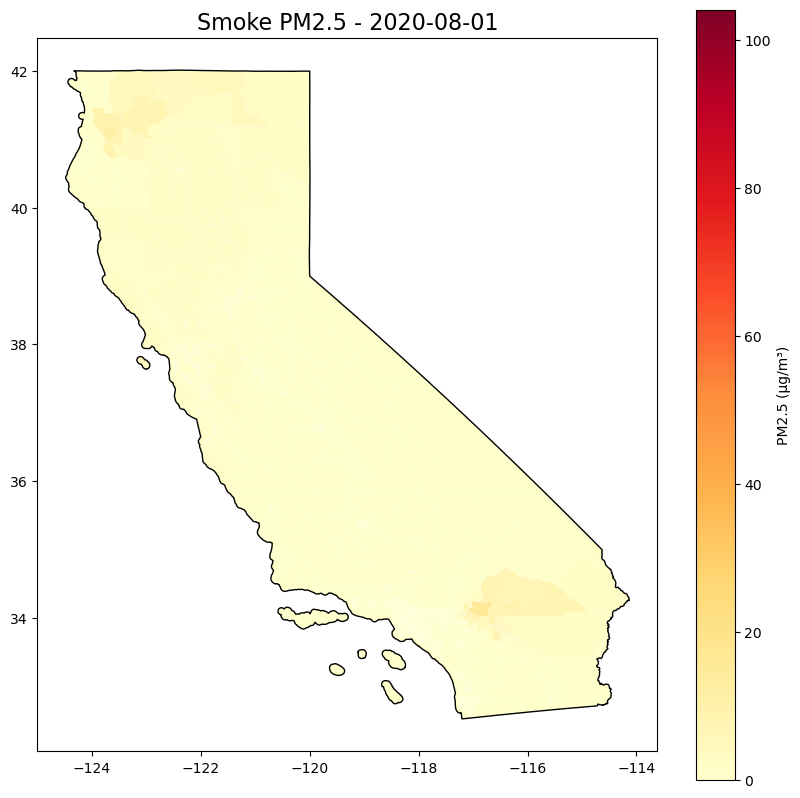

In [14]:
# set up animation
from matplotlib import animation

fig_smoke, ax_smoke = plt.subplots(figsize=(10,10))

california.plot(ax=ax_smoke, color='white')
california.boundary.plot(ax=ax_smoke, color='black', linewidth=1)

minx, miny, maxx, maxy = california.total_bounds
vmin = grid_final['smokePM_pred'].min()
vmax = grid_final['smokePM_pred'].quantile(0.99)

smoke_plot = grid_final[grid_final['date'] == dates[0]].plot(
    column='smokePM_pred', cmap='YlOrRd', vmin=vmin, vmax=vmax, legend=True, ax=ax_smoke,
    legend_kwds={'label': "PM2.5 (µg/m³)"}
)
title = ax_smoke.set_title(f"Smoke PM2.5 - {dates[0].date()}", fontsize=16)

# function to update each frame
def update_smoke(i):
    ax_smoke.clear()
    california.plot(ax=ax_smoke, color='white')
    california.boundary.plot(ax=ax_smoke, color='black', linewidth=1)
    grid_day = grid_final[grid_final['date'] == dates[i]]
    grid_day_plot = grid_day[grid_day.geometry.notna() & grid_day.geometry.apply(lambda g: g.is_valid if g is not None else False)]
    grid_day_plot = gpd.GeoDataFrame(grid_day_plot, geometry='geometry', crs=grid_final.crs)
    grid_day_plot.plot(
        column='smokePM_pred', cmap='YlOrRd', vmin=vmin, vmax=vmax,
        legend=False, ax=ax_smoke,legend_kwds={'label': "PM2.5 (µg/m³)"}
    )
    ax_smoke.set_xlim(minx, maxx)
    ax_smoke.set_ylim(miny, maxy)
    
    ax_smoke.set_title(f"Smoke PM2.5 - {dates[i].date()}", fontsize=16)
    ax_smoke.axis('off')

In [ ]:
anim_smoke = FuncAnimation(fig_smoke, update_smoke, frames=len(dates), interval=300)
HTML(anim_smoke.to_html5_video())

### Only mobility

In [ ]:
fig_mobility, ax_mobility = plt.subplots(figsize=(10,10))

california.plot(ax=ax_mobility, color='white')
california.boundary.plot(ax=ax_mobility, color='black', linewidth=1)

minx, miny, maxx, maxy = california.total_bounds
vmax = grid_final['anomaly_pct'].quantile(0.99)
vmin = -vmax

mobility_plot = grid_final[grid_final['date'] == dates[0]].plot(
    column='anomaly_pct', cmap='RdBu_r', vmin=vmin, vmax=vmax, legend=True, ax=ax_mobility,legend_kwds={'label': "mobility anomaly percent"}
)
title = ax_mobility.set_title(f"Mobility Anomaly - {dates[0].date()}", fontsize=16)

# function to update each frame
def update_mobility(i):
    ax_mobility.clear()
    california.plot(ax=ax_mobility, color='white')
    california.boundary.plot(ax=ax_mobility, color='black', linewidth=1)
    grid_day = grid_final[grid_final['date'] == dates[i]]
    grid_day.plot(
        column='anomaly_pct', cmap='RdBu_r', vmin=vmin, vmax=vmax,
        legend=False, ax=ax_mobility,legend_kwds={'label': "mobility anomaly percent"}
    )
    ax_mobility.set_xlim(minx, maxx)
    ax_mobility.set_ylim(miny, maxy)
    
    ax_mobility.set_title(f"Mobility Anomaly - {dates[i].date()}", fontsize=16)
    ax_mobility.axis('off')

In [ ]:
anim_mobility = FuncAnimation(fig_mobility, update_mobility, frames=len(dates), interval=300)
HTML(anim_mobility.to_html5_video())

### Side-by-side

In [ ]:
fig_side_by_side, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

minx, miny, maxx, maxy = california.total_bounds

vmin_smoke = grid_final['smokePM_pred'].min()
vmax_smoke = grid_final['smokePM_pred'].quantile(0.99)

vmax_mob = grid_final['anomaly_pct'].quantile(0.95)
vmin_mob = -vmax_mob

california.plot(ax=ax1, color='white')
california.boundary.plot(ax=ax1, color='black', linewidth=1)
smoke_plot = grid_final[grid_final['date'] == dates[0]].plot(
    column='smokePM_pred', cmap='YlOrRd', vmin=vmin_smoke, vmax=vmax_smoke,
    legend=True, ax=ax1, legend_kwds={'label': "PM2.5 (µg/m³)"}
)
ax1.set_title("Smoke PM2.5", fontsize=16)
ax1.axis('off')

california.plot(ax=ax2, color='white')
california.boundary.plot(ax=ax2, color='black', linewidth=1)
mobility_plot = grid_final[grid_final['date'] == dates[0]].plot(
    column='anomaly_pct', cmap='RdBu_r', vmin=vmin_mob, vmax=vmax_mob,
    legend=True, ax=ax2, legend_kwds={'label': "mobility anomaly percent"}
)
ax2.set_title("Mobility Anomaly", fontsize=16)
ax2.axis('off')

title_text = fig_side_by_side.text(0.5, 0.95,f"Smoke PM2.5 and Mobility Anomaly - {dates[0].date()}",ha='center',fontsize=20)

def update_side_by_side(i):
    ax1.clear()
    ax2.clear()
    
    # smoke
    california.plot(ax=ax1, color='white')
    california.boundary.plot(ax=ax1, color='black', linewidth=1)
    grid_day_smoke = grid_final[grid_final['date'] == dates[i]]
    grid_day_smoke.plot(
        column='smokePM_pred', cmap='YlOrRd', vmin=vmin_smoke, vmax=vmax_smoke,
        legend=False, ax=ax1, legend_kwds={'label': "PM2.5 (µg/m³)"}
    )
    ax1.set_xlim(minx, maxx)
    ax1.set_ylim(miny, maxy)
    ax1.set_title("Smoke PM2.5", fontsize=16)
    ax1.axis('off')
    
    # mobility
    california.plot(ax=ax2, color='white')
    california.boundary.plot(ax=ax2, color='black', linewidth=1)
    grid_day_mob = grid_final[grid_final['date'] == dates[i]]
    grid_day_mob.plot(
        column='anomaly_pct', cmap='RdBu_r', vmin=vmin_mob, vmax=vmax_mob,
        legend=False, ax=ax2, legend_kwds={'label': "mobility anomaly percent"}
    )
    ax2.set_xlim(minx, maxx)
    ax2.set_ylim(miny, maxy)
    ax2.set_title("Mobility Anomaly", fontsize=16)
    ax2.axis('off')

    title_text.set_text(f"Smoke PM2.5 and Mobility Anomaly - {dates[i].date()}")

In [ ]:
anim_side_by_side = FuncAnimation(fig_side_by_side, update_side_by_side, frames=len(dates), interval=300)
HTML(anim_side_by_side.to_html5_video())
# go into full screen to see both plots

### Overlay

In [ ]:
# define how the colors will overlay

vmin_smoke = grid_final['smokePM_pred'].min()
vmax_smoke = grid_final['smokePM_pred'].quantile(0.99)
vmax_mob = grid_final['anomaly_pct'].quantile(0.95)
vmin_mob = -vmax_mob

grid_final['smoke_norm'] = ((grid_final['smokePM_pred'] - vmin_smoke) / (vmax_smoke - vmin_smoke)).clip(0, 1)
grid_final['mob_norm'] = ((grid_final['anomaly_pct'] - vmin_mob) / (vmax_mob - vmin_mob)).clip(0, 1)

smoke = grid_final['smoke_norm'].values
mob = grid_final['mob_norm'].values

strength, base = 0.9, 1
R = base - strength * mob
G = base - strength * (smoke + mob)
B = base - strength * smoke

rgb = np.stack([R, G, B], axis=1)
rgb = np.clip(rgb, 0, 1)

grid_final['color'] = list(rgb)

In [ ]:
# legend
def smoke_mob_to_rgb(smoke, mob, strength, base):
    R = base - strength * mob
    G = base - strength * (smoke + mob)
    B = base - strength * smoke
    rgb = np.array([R, G, B])
    return np.clip(rgb, 0, 1)

smoke_vals = np.linspace(0, 1, 100)
mob_vals = np.linspace(0, 1, 100)
legend = np.zeros((100, 100, 3))
for i, s in enumerate(smoke_vals):
    for j, m in enumerate(mob_vals):
        legend[i, j] = smoke_mob_to_rgb(s, m, strength, base)

In [ ]:
fig_overlay, (ax, ax_leg) = plt.subplots(1, 2, figsize=(14, 7),gridspec_kw={'width_ratios': [2, 1]})

minx, miny, maxx, maxy = california.total_bounds

ax_leg.imshow(legend, origin='lower', extent=[0, 1, 0, 1])
ax_leg.set_title("Legend", fontsize=12)
ax_leg.set_xlabel("Mobility Anomaly (%)")
ax_leg.set_ylabel("Smoke PM2.5 (µg/m³)")
ax_leg.set_xticks([0, 0.5, 1])
ax_leg.set_xticklabels([f"{vmin_mob:.1f}","0",f"{vmax_mob:.1f}"])
ax_leg.set_yticks([0, 0.5, 1])
ax_leg.set_yticklabels([f"{vmin_smoke:.1f}",f"{(vmin_smoke+vmax_smoke)/2:.1f}",f"{vmax_smoke:.1f}"])
ax_leg.axvline(x=0.5, color='black', linestyle='--', linewidth=1)

california.plot(ax=ax, color='white')
california.boundary.plot(ax=ax, color='black', linewidth=1)
grid_day = grid_final[grid_final['date'] == dates[0]]
grid_day.plot(ax=ax,color=grid_day['color'].tolist())
ax.axis('off')

title_text = fig_overlay.text(0.5, 0.95,f"Smoke PM2.5 and Mobility Overlay - {dates[0].date()}",ha='center',fontsize=16)

def update_overlay(i):
    ax.clear()
    california.plot(ax=ax, color='white')
    california.boundary.plot(ax=ax, color='black', linewidth=1)
    
    grid_day = grid_final[grid_final['date'] == dates[i]]
    grid_day.plot(ax=ax,color=grid_day['color'].tolist())
    
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)    
    ax.axis('off')
    
    title_text.set_text(f"Smoke PM2.5 and Mobility Overlay - {dates[i].date()}")

In [ ]:
anim = FuncAnimation(fig_overlay,update_overlay,frames=len(dates),interval=300)
HTML(anim.to_html5_video())

### Next day mobility

In [ ]:
grid_final = grid_final.sort_values(['GEOID', 'date'])
grid_final['mob_norm_next_day'] = (grid_final.groupby('GEOID')['mob_norm'].shift(-1))

In [ ]:
mob_nd = grid_final['mob_norm_next_day'].values

strength, base = 0.9, 1
R_nd = base - strength * mob_nd
G_nd = base - strength * (smoke + mob_nd)
B_nd = base - strength * smoke

rgb_nd = np.stack([R_nd, G_nd, B_nd], axis=1)
rgb_nd = np.clip(rgb_nd, 0, 1)

grid_final['color_nd'] = list(rgb_nd)

In [ ]:
fig_nd, (ax, ax_leg) = plt.subplots(1, 2, figsize=(14, 7),gridspec_kw={'width_ratios': [2, 1]})

minx, miny, maxx, maxy = california.total_bounds

ax_leg.imshow(legend, origin='lower', extent=[0, 1, 0, 1])
ax_leg.set_title("Legend", fontsize=12)
ax_leg.set_xlabel("Next Day Mobility Anomaly (%)")
ax_leg.set_ylabel("Smoke PM2.5 (µg/m³)")
ax_leg.set_xticks([0, 0.5, 1])
ax_leg.set_xticklabels([f"{vmin_mob:.1f}","0",f"{vmax_mob:.1f}"])
ax_leg.set_yticks([0, 0.5, 1])
ax_leg.set_yticklabels([f"{vmin_smoke:.1f}",f"{(vmin_smoke+vmax_smoke)/2:.1f}",f"{vmax_smoke:.1f}"])
ax_leg.axvline(x=0.5, color='black', linestyle='--', linewidth=1)

california.plot(ax=ax, color='white')
california.boundary.plot(ax=ax, color='black', linewidth=1)
grid_day = grid_final[grid_final['date'] == dates[0]]
grid_day.plot(ax=ax,color=grid_day['color_nd'].tolist())
ax.axis('off')

title_text = fig_nd.text(0.5, 0.95,f"Smoke PM2.5 and Next Day Mobility Overlay - {dates[0].date()}",ha='center',fontsize=16)

def update_overlay(i):
    ax.clear()
    california.plot(ax=ax, color='white')
    california.boundary.plot(ax=ax, color='black', linewidth=1)
    
    grid_day = grid_final[grid_final['date'] == dates[i]]
    grid_day.plot(ax=ax,color=grid_day['color_nd'].tolist())
    
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)    
    ax.axis('off')
    
    title_text.set_text(f"Smoke PM2.5 and Next Day Mobility Overlay - {dates[i].date()}")

In [ ]:
anim = FuncAnimation(fig_nd,update_overlay,frames=len(dates)-1,interval=300)
HTML(anim.to_html5_video())